#📌 Extracción

In [17]:
import pandas as pd
import json

with open('TelecomX_Data.json', 'r') as archivo:
    datos_crudos = json.load(archivo)

df = pd.json_normalize(datos_crudos)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
# account.Charges.Total aparece como tipo object (texto)

In [ ]:
# El argumento errors='coerce' fuerza a que cualquier texto (como los espacios en blanco) se convierta en NaN (nulo)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Rellenar
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

# Verificar
print("Valores nulos actuales en la columna:", df['account.Charges.Total'].isnull().sum())
print("Nuevo tipo de dato de la columna:", df['account.Charges.Total'].dtype)

Valores nulos actuales en la columna: 0
Nuevo tipo de dato de la columna: float64


In [18]:
# 1) Crear la columna "Cuentas_Diarias"
# Es importante determinar el cargo mensual entre 30 (promedio de días de un mes) y redondeamos a 2 decimales
df['Cuentas_Diarias'] = round(df['account.Charges.Monthly'] / 30, 2)


# 2) Renombrar las columnas al español para facilitar la lectura a los stakeholders
diccionario_nombres = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion', # o Fuga/Cancelacion
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.Partner': 'Pareja',
    'customer.Dependents': 'Dependientes',
    'customer.tenure': 'Meses_Contrato',
    'phone.PhoneService': 'Serv_Telefonico',
    'phone.MultipleLines': 'Multiples_Lineas',
    'internet.InternetService': 'Serv_Internet',
    'internet.OnlineSecurity': 'Seguridad_Online',
    'internet.OnlineBackup': 'Respaldo_Online',
    'internet.DeviceProtection': 'Proteccion_Dispositivo',
    'internet.TechSupport': 'Soporte_Tecnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Peliculas',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Factura_Electronica',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Monthly': 'Cargo_Mensual',
    'account.Charges.Total': 'Cargo_Total'
}

df.rename(columns=diccionario_nombres, inplace=True)


# 3) Estandarización a valores binarios (1 y 0)
# Usamos un diccionario de mapeo. También incluimos los valores "No internet service"
# y "No phone service" como 0, ya que en la práctica significan que no tienen el servicio.
mapeo_binario = {
    'Yes': 1,
    'No': 0,
    'No internet service': 0,
    'No phone service': 0
}

# Aplicamos el reemplazo a todo el DataFrame
df.replace(mapeo_binario, inplace=True)

# Visualizamos cómo quedó nuestro DataFrame transformado
df.head()

/tmp/ipykernel_575/1204816797.py:45: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(mapeo_binario, inplace=True)


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Serv_Telefonico,Multiples_Lineas,Serv_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.4,2.80


#📊 Carga y análisis

ESTADÍSTICAS DESCRIPTIVAS DE LAS VARIABLES NUMÉRICAS 

       Meses_Contrato  Cargo_Mensual  Cuentas_Diarias
count         7043.00        7043.00          7043.00
mean            32.37          64.76             2.16
std             24.56          30.09             1.00
min              0.00          18.25             0.61
25%              9.00          35.50             1.18
50%             29.00          70.35             2.34
75%             55.00          89.85             2.99
max             72.00         118.75             3.96


👥 Total de clientes analizados: 7043
✅ Clientes Retenidos (0): 5174 (73.5%)
❌ Clientes Evadidos (1): 1869 (26.5%)


/tmp/ipykernel_575/3051489091.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Evasion', palette=['#2ECC71', '#E74C3C'])


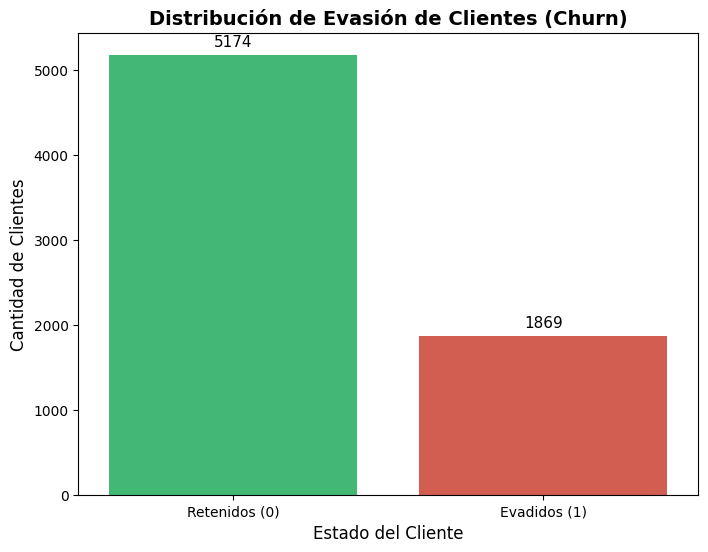

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pasos 1 y 2 de Carga de análisis
# --- 0. Limpieza final de la variable objetivo ---
# Filtramos los clientes que no tienen información de Evasión (los que quedaron como vacíos '')
# También nos aseguramos de que la columna sea numérica
df = df[df['Evasion'] != '']
df['Evasion'] = pd.to_numeric(df['Evasion'])

# --- 1. Análisis Descriptivo ---
print("ESTADÍSTICAS DESCRIPTIVAS DE LAS VARIABLES NUMÉRICAS \n")
# Seleccionamos solo algunas columnas numéricas clave para no saturar la pantalla
columnas_numericas = ['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias']
print(df[columnas_numericas].describe().round(2))
print("\n" + "="*50 + "\n")

# --- 2. Distribución de la Evasión (Churn) ---
# Calculamos los porcentajes exactos
retenidos = (df['Evasion'] == 0).sum()
evadidos = (df['Evasion'] == 1).sum()
total = len(df)

print(f"👥 Total de clientes analizados: {total}")
print(f"✅ Clientes Retenidos (0): {retenidos} ({round(retenidos/total*100, 1)}%)")
print(f"❌ Clientes Evadidos (1): {evadidos} ({round(evadidos/total*100, 1)}%)")

# Gráfico visual
plt.figure(figsize=(8, 6))
# Usamos un gráfico de barras (countplot) de Seaborn
ax = sns.countplot(data=df, x='Evasion', palette=['#2ECC71', '#E74C3C'])

# Personalizamos el gráfico para que se vea profesional
plt.title('Distribución de Evasión de Clientes (Churn)', fontsize=14, fontweight='bold')
plt.xlabel('Estado del Cliente', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Retenidos (0)', 'Evadidos (1)'])

# Números encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11)

plt.show()

Generando gráficos de variables categóricas...



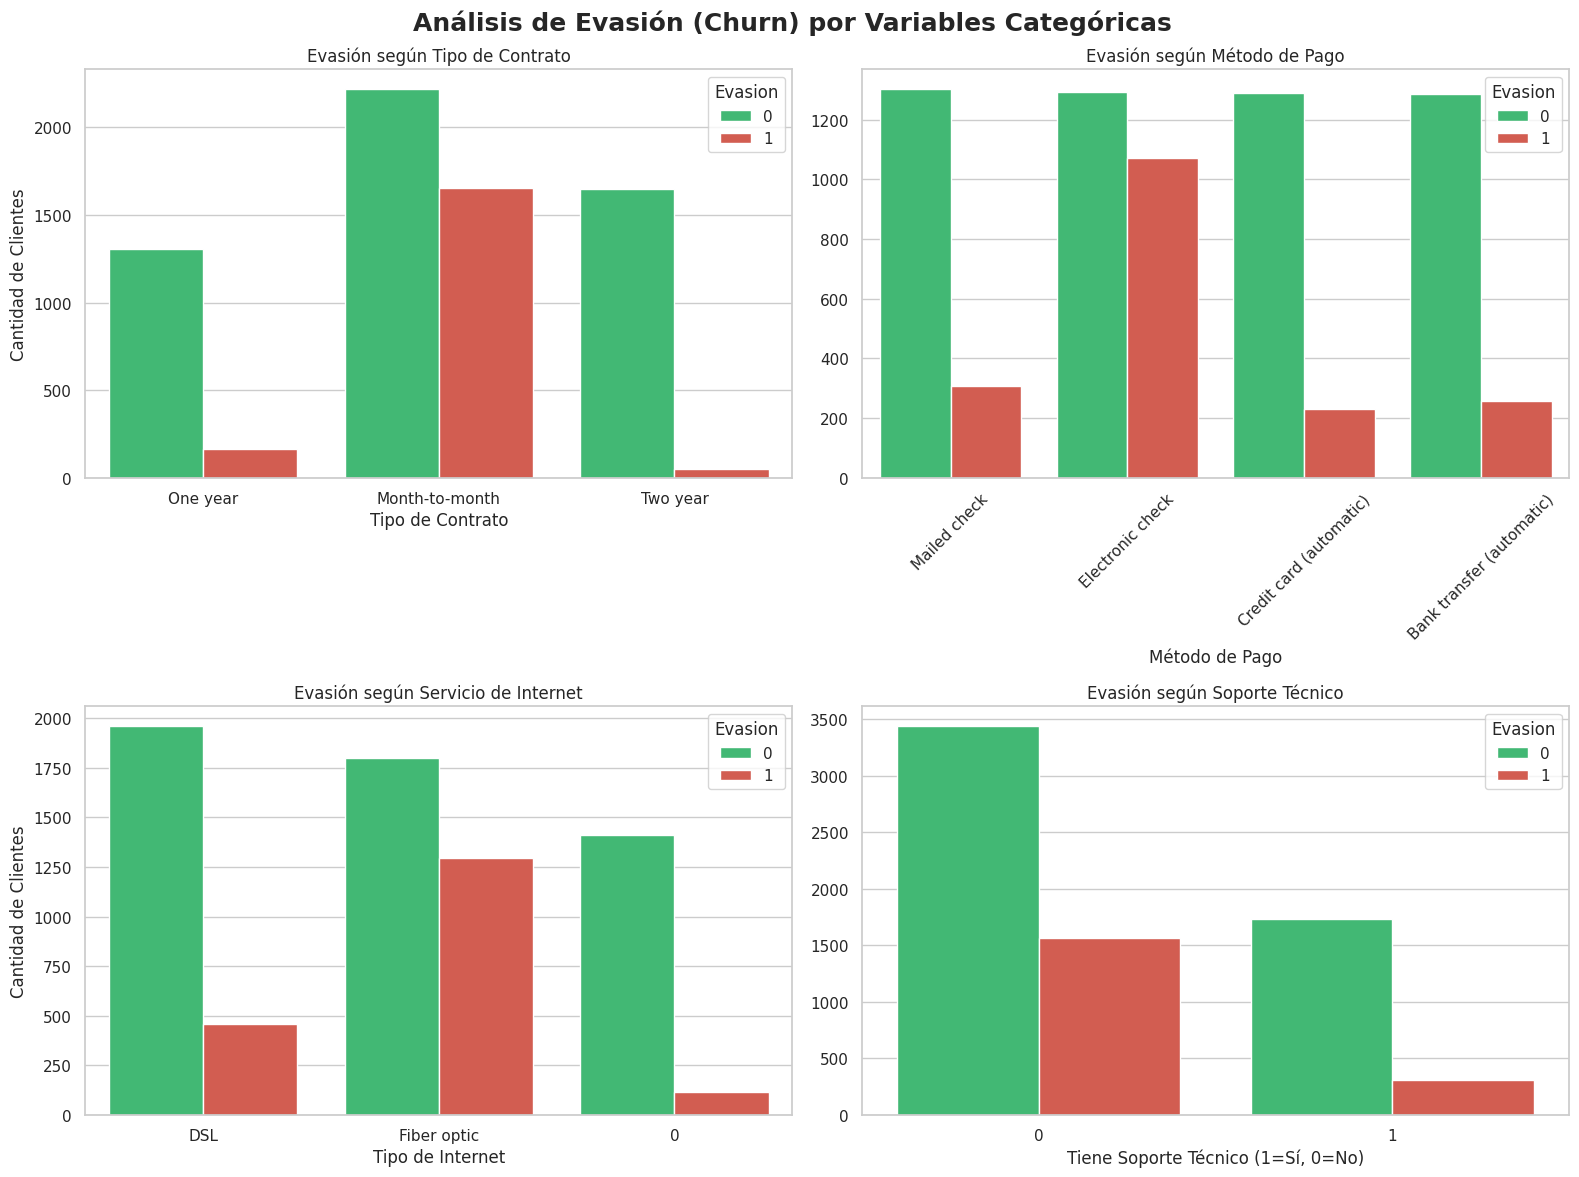


Generando gráficos de variables numéricas (Tiempo y Gasto)...



/tmp/ipykernel_575/962788077.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Evasion', y='Meses_Contrato', palette=['#2ECC71', '#E74C3C'], ax=axes[0])
/tmp/ipykernel_575/962788077.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Evasion', y='Cargo_Total', palette=['#2ECC71', '#E74C3C'], ax=axes[1])
/tmp/ipykernel_575/962788077.py:60: UserWarning: 
The palette list has fewer values (2) than needed (6531) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df, x='Evasion', y='Cargo_Total', palette=['#2ECC71', '#E74C3C'], ax=axes[1])


KeyboardInterrupt: 

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general de estilo
sns.set_theme(style="whitegrid")

# ==========================================
# PASO 3: EVASIÓN POR VARIABLES CATEGÁRICAS
# ==========================================
print("Generando gráficos de variables categóricas...\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis de Evasión (Churn) por Variables Categóricas', fontsize=18, fontweight='bold')

# 3.1 Tipo de Contrato vs Evasión
sns.countplot(data=df, x='Tipo_Contrato', hue='Evasion', palette=['#2ECC71', '#E74C3C'], ax=axes[0,0])
axes[0,0].set_title('Evasión según Tipo de Contrato')
axes[0,0].set_xlabel('Tipo de Contrato')
axes[0,0].set_ylabel('Cantidad de Clientes')

# 3.2 Método de Pago vs Evasión
sns.countplot(data=df, x='Metodo_Pago', hue='Evasion', palette=['#2ECC71', '#E74C3C'], ax=axes[0,1])
axes[0,1].set_title('Evasión según Método de Pago')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].set_xlabel('Método de Pago')
axes[0,1].set_ylabel('')

# 3.3 Servicio de Internet vs Evasión
sns.countplot(data=df, x='Serv_Internet', hue='Evasion', palette=['#2ECC71', '#E74C3C'], ax=axes[1,0])
axes[1,0].set_title('Evasión según Servicio de Internet')
axes[1,0].set_xlabel('Tipo de Internet')
axes[1,0].set_ylabel('Cantidad de Clientes')

# 3.4 Soporte Técnico vs Evasión
sns.countplot(data=df, x='Soporte_Tecnico', hue='Evasion', palette=['#2ECC71', '#E74C3C'], ax=axes[1,1])
axes[1,1].set_title('Evasión según Soporte Técnico')
axes[1,1].set_xlabel('Tiene Soporte Técnico (1=Sí, 0=No)')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.show()


# ==========================================
# PASO 4: EVASIÓN POR VARIABLES NUMÉRICAS
# ==========================================
print("\nGenerando gráficos de variables numéricas (Tiempo y Gasto)...\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribución de Variables Numéricas vs Evasión', fontsize=16, fontweight='bold')

# 4.1 Tiempo de Contrato (Meses) vs Evasión
# Usamos un boxplot (diagrama de caja) que es ideal para ver cómo se distribuyen los números
sns.boxplot(data=df, x='Evasion', y='Meses_Contrato', palette=['#2ECC71', '#E74C3C'], ax=axes[0])
axes[0].set_title('Tiempo de Contrato vs Evasión', fontsize=14)
axes[0].set_xlabel('Evasión (0 = Se Queda, 1 = Cancela)')
axes[0].set_ylabel('Meses de Contrato')

# 4.2 Total Gastado vs Evasión
sns.boxplot(data=df, x='Evasion', y='Cargo_Total', palette=['#2ECC71', '#E74C3C'], ax=axes[1])
axes[1].set_title('Total Gastado vs Evasión', fontsize=14)
axes[1].set_xlabel('Evasión (0 = Se Queda, 1 = Cancela)')
axes[1].set_ylabel('Cargo Total Acumulado ($)')

plt.tight_layout()
plt.show()

#📄Informe final

Informe Final:

Análisis de Evasión de Clientes (Churn) - Telecom X
# **Introducción**

Telecom X se enfrenta a un desafío crítico: una alta tasa de cancelación de servicios por parte de sus clientes, fenómeno conocido como Churn o Evasión. Este proyecto de análisis de datos tiene como objetivo principal diseccionar la base de datos de clientes para comprender a profundidad los factores demográficos, de servicio y financieros que impulsan estas cancelaciones. Al transformar estos datos crudos en información estratégica, sentamos las bases para que el equipo de Data Science desarrolle modelos predictivos (Machine Learning) e implemente medidas proactivas de retención.

# **Limpieza y Tratamiento de Datos (ETL)**
Para garantizar la integridad del análisis, se llevó a cabo un riguroso proceso de Extracción, Transformación y Carga (ETL):

Extracción y Aplanamiento: Los datos fueron importados desde un formato JSON estructurado y anidado. Utilizando Pandas (pd.json_normalize), se aplanaron las estructuras para convertir diccionarios complejos en columnas tabulares accesibles.

Corrección de Tipos de Datos: Se identificó que la variable Cargo_Total estaba codificada como texto debido a valores en blanco pertenecientes a clientes nuevos (0 meses de antigüedad). Estos valores fueron imputados con 0 y la columna se transformó a formato numérico (float64).

Feature Engineering y Estandarización: * Se creó la nueva métrica Cuentas_Diarias a partir del cargo mensual para tener una visión más granular del gasto.

Se renombraron todas las columnas al español para facilitar la comunicación con los stakeholders.

Se transformaron las variables categóricas binarias ("Yes"/"No") a formato numérico (1 y 0), preparando el dataset para futuros algoritmos de Machine Learning.

Se excluyeron los registros sin información en la variable objetivo (Evasion).

# **Análisis Exploratorio de Datos (EDA)**
Durante la fase visual, se descubrieron los siguientes patrones de comportamiento:

Desbalance de Clases: La tasa de evasión base de la compañía se sitúa en un 26.5%, lo que representa una fuga significativa de capital, aunque la mayoría de los clientes (73.5%) se mantienen retenidos.

El Riesgo del Corto Plazo: Los diagramas de caja revelaron que la mediana de permanencia de los clientes que abandonan es de apenas 10 meses. La fuga ocurre principalmente en la etapa temprana del ciclo de vida del cliente.

Sensibilidad al Precio: Los clientes que cancelan muestran una clara tendencia a poseer un Cargo Mensual más alto.

Servicios e Infraestructura: Los contratos "Mes a Mes" (Month-to-month) y el método de pago por "Cheque Electrónico" concentran la inmensa mayoría de las deserciones. Sorprendentemente, los usuarios de "Fibra Óptica" cancelan en mayor proporción que los de "DSL".

# **Conclusiones e Insights**
La evasión en Telecom X no es un evento aleatorio, sino un patrón predecible fuertemente ligado a la falta de compromiso a largo plazo y a la fricción en la relación costo-beneficio.
Los clientes entran a la compañía probando el servicio mediante contratos mensuales y, al enfrentarse a cargos mensuales elevados (potencialmente impulsados por servicios como la Fibra Óptica), deciden darse de baja antes de cumplir su primer año. El método de pago manual (cheques electrónicos) también facilita la cancelación al requerir una acción activa de pago mes a mes, a diferencia de los cobros automáticos.

# Recomendaciones Estratégicas *

Para reducir la evasión de manera efectiva, se sugieren las siguientes iniciativas:

Fomentar Contratos a Largo Plazo: Diseñar campañas agresivas de upselling que

1.   ofrezcan descuentos significativos en el "Cargo Mensual" si el cliente migra de un plan "Mes a Mes" a un contrato de 1 o 2 años.
2.   Programa de Retención Temprana: Dado que la fuga se concentra en los primeros 10 a 15 meses, implementar un sistema de soporte y seguimiento especializado para nuevos clientes ("Onboarding Premium") durante su primer año.
3. Auditoría de Fibra Óptica: Investigar la discrepancia en el servicio de Fibra Óptica. Si la alta tasa de cancelación se debe a fallas técnicas, se debe mejorar la infraestructura; si se debe al precio, evaluar un ajuste de tarifas.
4. Incentivar Pagos Automáticos: Ofrecer pequeñas bonificaciones o eliminar cargos por servicio a aquellos clientes que cambien su método de pago de "Cheque Electrónico" a cobro automático por tarjeta de crédito o transferencia bancaria







.



